Data sample:
         Date    Open    High     Low   Close   Volume
0  2025-09-01  2930.0  2950.0  2920.0  2945.0  1500000
1  2025-09-02  2945.0  2960.0  2930.0  2955.0  1400000
2  2025-09-03  2955.0  2970.0  2940.0  2960.0  1550000
3  2025-09-04  2960.0  2980.0  2950.0  2975.0  1450000
4  2025-09-05  2975.0  2990.0  2960.0  2985.0  1600000

Model Evaluation Metrics:
Mean Squared Error (MSE): 49.1746
Mean Absolute Error (MAE): 6.4935
R² Score: 0.7805


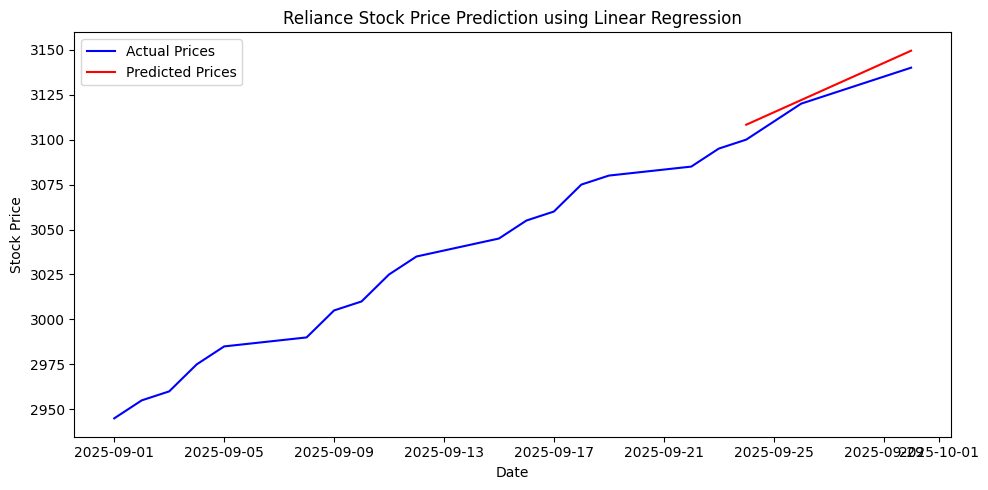


Predicted Stock Prices for Next 10 Days:
2025-10-01 : ₹3156.30
2025-10-02 : ₹3163.16
2025-10-03 : ₹3170.02
2025-10-04 : ₹3176.88
2025-10-05 : ₹3183.74
2025-10-06 : ₹3190.59
2025-10-07 : ₹3197.45
2025-10-08 : ₹3204.31
2025-10-09 : ₹3211.17
2025-10-10 : ₹3218.03

Predictions saved to reliance_predictions.csv


"\nfrom sklearn.preprocessing import StandardScaler\n\nscaler = StandardScaler()\nX_train_scaled = scaler.fit_transform(X_train)\nX_test_scaled = scaler.transform(X_test)\n\nmodel.fit(X_train_scaled, y_train)\ny_pred_scaled = model.predict(X_test_scaled)\n\nprint('Scaled model R²:', r2_score(y_test, y_pred_scaled))\n"

In [ ]:
# stock_price_prediction.py

# -----------------------------
#  Importing libraries
# -----------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
# 1. Loading CSV Data
# -----------------------------

data = pd.read_csv("reliance.csv")

print("Data sample:")
print(data.head())

# -----------------------------
# 2. Preparing the data
# -----------------------------

data = data[['Date', 'Close']]

# Converting 'Date' to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Converting dates to ordinal (numeric format)
data['Date_ordinal'] = data['Date'].map(pd.Timestamp.toordinal)

# Creating features (X) and labels (y)
X = np.array(data['Date_ordinal']).reshape(-1, 1)
y = np.array(data['Close'])

# -----------------------------
# 3. Splitting into training and test sets
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# -----------------------------
# 4. Training Linear Regression model
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------
# 5. Making predictions on test data
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# 6. Evaluating the model
# -----------------------------
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# -----------------------------
# 7. Visualizing Actual vs Predicted
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(data['Date'], y, label='Actual Prices', color='blue')

# Aligning dates for the predicted test data
test_dates = data['Date'].iloc[len(X_train):len(X_train) + len(y_pred)]
plt.plot(test_dates, y_pred, label='Predicted Prices', color='red')

plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Reliance Stock Price Prediction using Linear Regression")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 8. Predicting Next 10 Days (Future Forecast)
# -----------------------------
future_days = 10
last_date = data['Date'].iloc[-1]

# Generating next 10 calendar days
future_dates = [last_date + pd.Timedelta(days=i) for i in range(1, future_days + 1)]
future_ordinal = np.array([d.toordinal() for d in future_dates]).reshape(-1, 1)

# Predicting future stock prices
future_predictions = model.predict(future_ordinal)

print("\nPredicted Stock Prices for Next 10 Days:")
for date, price in zip(future_dates, future_predictions):
    print(f"{date.date()} : ₹{price:.2f}")

# -----------------------------
# -----------------------------
pred_df = pd.DataFrame({
    'Date': test_dates,
    'Actual_Price': y_test,
    'Predicted_Price': y_pred
})
pred_df.to_csv('reliance_predictions.csv', index=False)
print("\nPredictions saved to reliance_predictions.csv")


"""
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled, y_train)
y_pred_scaled = model.predict(X_test_scaled)

print('Scaled model R²:', r2_score(y_test, y_pred_scaled))
"""

